# Next-Generation Juvenile Mortality Table
## Predictive Analytics Framework — Pipeline Demo

**Audience:** SOA Mortality Working Group / Actuarial Review Panel  
**Data:** ILEC 2012–2019 Individual Life Experience Study (Issue Ages 0–17)  
**Benchmark:** VBT 2015 Primary Tables  

---

This notebook walks through the full analytical pipeline:

| Module | Purpose |
|--------|---|
| **1**  | Data load from Parquet cache + overview |
| **2**  | A/E ratios, confidence intervals, PCA structural comparison |
| **3**  | Crude qx, GBM feature importance + SHAP, Poisson GAM smoothing |
| **4**  | Monotonicity validation, log-linear grading into adult table |
| **5**  | Key findings summary |

---
## 1 · Setup & Data Load

In [58]:
import sys, warnings, logging
warnings.filterwarnings("ignore")
logging.basicConfig(level=logging.WARNING)

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns

# ── project root on path ──────────────────────────────────────────────────
ROOT = Path(".").resolve()
sys.path.insert(0, str(ROOT))

from config import (
    ACTUAL_CNT_COL, EXPECTED_CNT_COL,
    ACTUAL_AMT_COL, EXPECTED_AMT_COL,
    EXPOSURE_CNT,   EXPOSURE_AMT,
    DEFAULT_DATA_PATH,
)
from src.data_loader       import JuvenileDataLoader
from src.actuarial_metrics import compute_ae_ratios, ae_confidence_intervals, compare_juvenile_adult_pca
from src.mortality_models  import compute_crude_qx, run_feature_importance, fit_mortality_gam
from src.model_validation  import validation_report

# ── plot style ────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.15)
BLUE, ORANGE, GREEN, RED = "#2563EB", "#EA580C", "#16A34A", "#DC2626"
FIG_W, FIG_H = 12, 5

print("Libraries loaded.")

Libraries loaded.


In [59]:
# ── Load from Parquet cache (fast) or fall back to source CSV ─────────────
PARQUET_CACHE = ROOT / "data" / "juvenile_cache.parquet"

loader = JuvenileDataLoader(
    path=DEFAULT_DATA_PATH,
    parquet_cache=PARQUET_CACHE,
    verbose=False,
)
df = loader.load()

print(loader.summary())

Source     : Juvenile_cleaned.txt
Raw rows   : (loaded from Parquet cache: C:\Users\haofe\PycharmProjects\Juvenile\juvenile_mortality\data\juvenile_cache.parquet)
Final rows : 1,432,036
Exclusions :
Columns    : 28
Exposure   : 48,324,880 policies
Deaths     : 285,788


### 0.1 · Dataset Snapshot

In [62]:
overview_cols = [
    "Attained_Age", "Issue_Age", "Duration",
    "Sex", "Smoker_Status", "Insurance_Plan",
    "Attained_Age_Group", "Policy_Year_Group",
    "Death_Count", "Policies_Exposed",
    EXPECTED_CNT_COL,
]
present = [c for c in overview_cols if c in df.columns]
display(df[present].head(8))
print(f"\nShape: {df.shape[0]:,} rows  ×  {df.shape[1]} columns")
print(f"Policy exposure : {df[EXPOSURE_CNT].sum():>15,.0f} policy-years")
print(f"Actual deaths   : {df[ACTUAL_CNT_COL].sum():>15,.0f}")
print(f"Expected deaths : {df[EXPECTED_CNT_COL].sum():>15,.0f}")
print(f"Overall A/E     : {df[ACTUAL_CNT_COL].sum() / df[EXPECTED_CNT_COL].sum():.4f}")

,Attained_Age,Issue_Age,Duration,Sex,Smoker_Status,Insurance_Plan,Attained_Age_Group,Policy_Year_Group,Death_Count,Policies_Exposed,ExpDth_VBT2015_Cnt
0,1,1,1,F,U,Perm,0–4,1–5,0,83.606804,0.010033
1,1,1,1,F,U,Perm,0–4,1–5,0,148.938843,0.017873
2,2,1,2,F,U,Perm,0–4,1–5,0,76.386971,0.006111
3,2,1,2,F,U,Perm,0–4,1–5,0,122.274033,0.009782
4,2,1,2,F,U,Perm,0–4,1–5,0,115.449768,0.009236
5,2,1,2,F,U,Perm,0–4,1–5,0,34.458858,0.002757
6,3,1,3,F,U,Perm,0–4,1–5,0,1.838356,0.000129
7,3,1,3,F,U,Perm,0–4,1–5,0,1.830602,0.000128



Shape: 1,432,036 rows  ×  28 columns
Policy exposure :      48,324,880 policy-years
Actual deaths   :         285,788
Expected deaths :         283,629
Overall A/E     : 1.0076


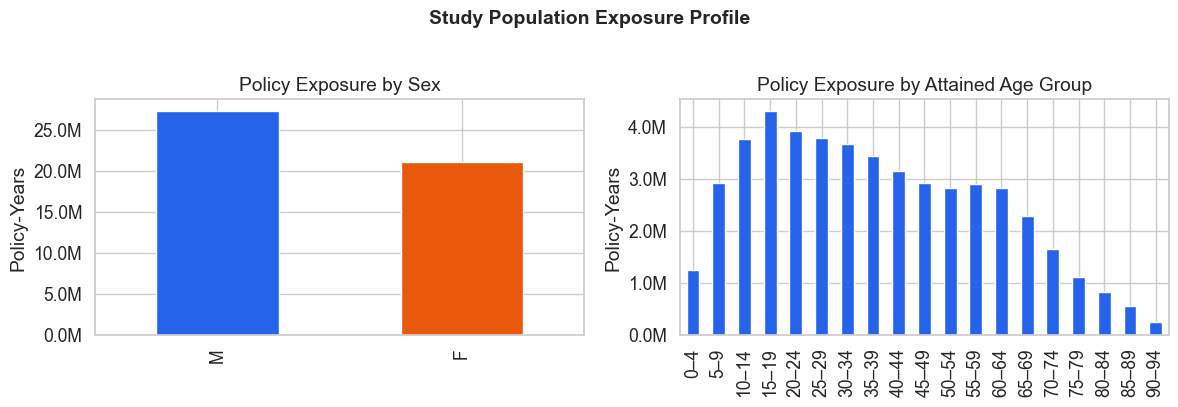

In [63]:
# Exposure distribution by sex
fig, axes = plt.subplots(1, 2, figsize=(FIG_W, FIG_H - 1))

sex_exp = (
    df.groupby("Sex", observed=True)[EXPOSURE_CNT].sum()
    .sort_values(ascending=False)
)
sex_exp.plot.bar(ax=axes[0], color=[BLUE, ORANGE, GREEN], edgecolor="white")
axes[0].set_title("Policy Exposure by Sex")
axes[0].set_ylabel("Policy-Years")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
axes[0].set_xlabel("")

age_exp = (
    df.groupby("Attained_Age_Group", observed=True)[EXPOSURE_CNT].sum()
)
age_exp.plot.bar(ax=axes[1], color=BLUE, edgecolor="white")
axes[1].set_title("Policy Exposure by Attained Age Group")
axes[1].set_ylabel("Policy-Years")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
axes[1].set_xlabel("")

plt.suptitle("Study Population Exposure Profile", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

---
## 2 · Actuarial Metrics & EDA

### 2.1 · A/E Ratios — Sex × Age Group

The **A/E ratio** (Actual ÷ Expected) measures how observed juvenile mortality compares to the VBT 2015 benchmark.  
- **A/E > 1** → higher mortality than expected  
- **A/E < 1** → lower mortality than expected  
- CIs use the Poisson normal approximation: $SE(A/E) = A/E \,/\, \sqrt{D}$

In [64]:
ae = compute_ae_ratios(df, groupby=["Sex", "Attained_Age_Group"])
ae = ae_confidence_intervals(ae)

display_cols = [
    "Sex", "Attained_Age_Group", "Policies_Exposed",
    "Death_Count", "Exp_Count",
    "AE_Count", "AE_Count_CI_Lo", "AE_Count_CI_Hi",
    "AE_Amount", "Credibility_Count",
]
display(ae[[c for c in display_cols if c in ae.columns]]
        .style
        .format({
            "Policies_Exposed": "{:,.0f}",
            "Death_Count":      "{:,.0f}",
            "Exp_Count":        "{:,.1f}",
            "AE_Count":         "{:.4f}",
            "AE_Count_CI_Lo":   "{:.4f}",
            "AE_Count_CI_Hi":   "{:.4f}",
            "AE_Amount":        "{:.4f}",
            "Credibility_Count":"{:.3f}",
        })
        .background_gradient(subset=["AE_Count"], cmap="RdYlGn_r", vmin=0.7, vmax=1.4)
        .set_caption("A/E Ratios — Count & Amount Basis  |  95% CI  |  LLID Credibility")
)

,Sex,Attained_Age_Group,Policies_Exposed,Death_Count,Exp_Count,AE_Count,AE_Count_CI_Lo,AE_Count_CI_Hi,AE_Amount,Credibility_Count
0,F,0–4,"616,045",43,49.2,0.8733,0.6123,1.1343,0.6717,0.199
1,F,5–9,"1,437,415",99,101.9,0.9712,0.7799,1.1625,0.5635,0.302
2,F,10–14,"1,858,936",169,150.3,1.1244,0.9549,1.2939,0.8887,0.395
3,F,15–19,"2,129,964",549,515.9,1.0641,0.9751,1.1531,0.7883,0.712
4,F,20–24,"1,925,090",731,605.1,1.2081,1.1205,1.2957,0.9784,0.822
5,F,25–29,"1,843,965",966,659.4,1.4650,1.3726,1.5574,1.2135,0.945
6,F,30–34,"1,771,483","1,283",841.5,1.5247,1.4413,1.6082,1.3084,1.000
7,F,35–39,"1,626,679","1,702","1,260.3",1.3505,1.2863,1.4146,1.1023,1.000
8,F,40–44,"1,454,069","2,135","1,525.7",1.3994,1.3400,1.4587,1.1355,1.000
9,F,45–49,"1,290,653","2,684","1,791.1",1.4986,1.4419,1.5552,1.2634,1.000


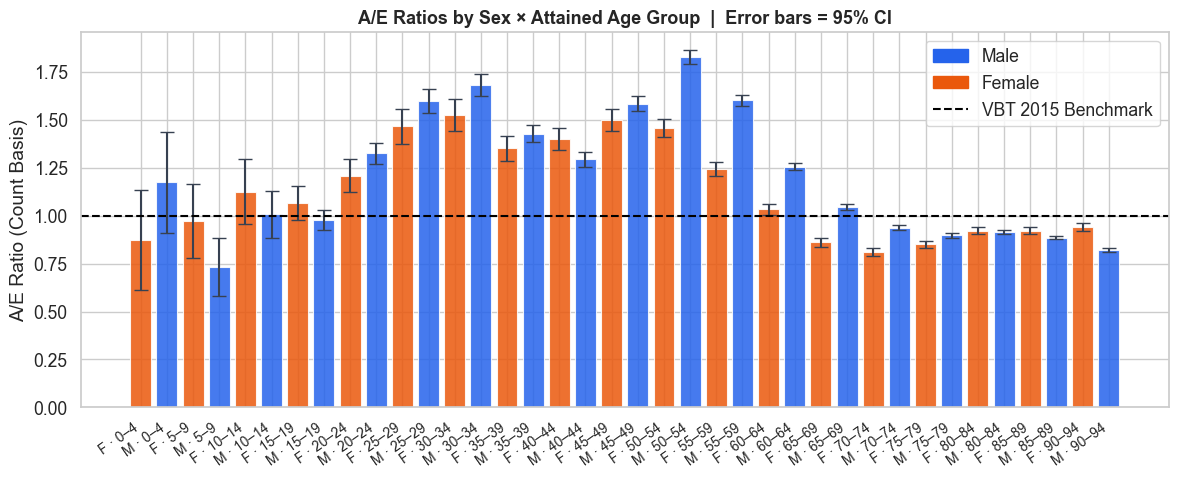

In [65]:
fig, ax = plt.subplots(figsize=(FIG_W, FIG_H))

ae_plot = ae.dropna(subset=["AE_Count"]).sort_values(["Attained_Age_Group", "Sex"])
labels  = ae_plot["Sex"].astype(str) + " · " + ae_plot["Attained_Age_Group"].astype(str)
x       = np.arange(len(ae_plot))
yerr_lo = (ae_plot["AE_Count"] - ae_plot["AE_Count_CI_Lo"]).values
yerr_hi = (ae_plot["AE_Count_CI_Hi"] - ae_plot["AE_Count"]).values

colors = [BLUE if s == "M" else ORANGE for s in ae_plot["Sex"].astype(str)]
bars   = ax.bar(x, ae_plot["AE_Count"], color=colors, alpha=0.85,
                edgecolor="white", linewidth=0.8)
ax.errorbar(x, ae_plot["AE_Count"], yerr=[yerr_lo, yerr_hi],
            fmt="none", color="#374151", capsize=5, linewidth=1.5)

ax.axhline(1.0, color="black", linewidth=1.5, linestyle="--", label="VBT 2015 (A/E = 1.00)")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=35, ha="right", fontsize=10)
ax.set_ylabel("A/E Ratio (Count Basis)")
ax.set_title("A/E Ratios by Sex × Attained Age Group  |  Error bars = 95% CI",
             fontsize=13, fontweight="bold")

legend_handles = [
    mpatches.Patch(color=BLUE,   label="Male"),
    mpatches.Patch(color=ORANGE, label="Female"),
    plt.Line2D([0], [0], color="black", linestyle="--", label="VBT 2015 Benchmark"),
]
ax.legend(handles=legend_handles, loc="upper right")
plt.tight_layout()
plt.show()

### 2.2 · A/E by Attained Age — Full Curve with Confidence Ribbon

In [66]:
ae_age = compute_ae_ratios(df, groupby=["Attained_Age"])
ae_age = ae_confidence_intervals(ae_age)
ae_age = ae_age.sort_values("Attained_Age")

display(ae_age[["Attained_Age", "Policies_Exposed", "Death_Count",
               "Exp_Count", "AE_Count", "AE_Count_CI_Lo", "AE_Count_CI_Hi",
               "Credibility_Count"]]
        .head(25)
        .style
        .format({
            "Policies_Exposed": "{:,.0f}",
            "Death_Count":      "{:,.0f}",
            "Exp_Count":        "{:,.2f}",
            "AE_Count":         "{:.4f}",
            "AE_Count_CI_Lo":   "{:.4f}",
            "AE_Count_CI_Hi":   "{:.4f}",
            "Credibility_Count":"{:.3f}",
        })
        .background_gradient(subset=["AE_Count"], cmap="RdYlGn_r", vmin=0.6, vmax=1.6)
        .set_caption("A/E by Attained Age — first 25 ages")
)

,Attained_Age,Policies_Exposed,Death_Count,Exp_Count,AE_Count,AE_Count_CI_Lo,AE_Count_CI_Hi,Credibility_Count
0,1,"171,625",26,22.77,1.1417,0.7029,1.5806,0.155
1,2,"278,714",27,27.93,0.9668,0.6022,1.3315,0.158
2,3,"361,883",36,30.80,1.1689,0.7870,1.5507,0.182
3,4,"430,202",31,33.39,0.9284,0.6016,1.2552,0.169
4,5,"488,809",36,39.16,0.9194,0.6191,1.2197,0.182
5,6,"540,938",38,41.92,0.9065,0.6183,1.1947,0.187
6,7,"586,811",30,44.05,0.6811,0.4373,0.9248,0.167
7,8,"627,811",37,47.13,0.7851,0.5322,1.0381,0.185
8,9,"666,084",46,50.00,0.9200,0.6541,1.1859,0.206
9,10,"699,203",58,54.27,1.0687,0.7937,1.3438,0.232


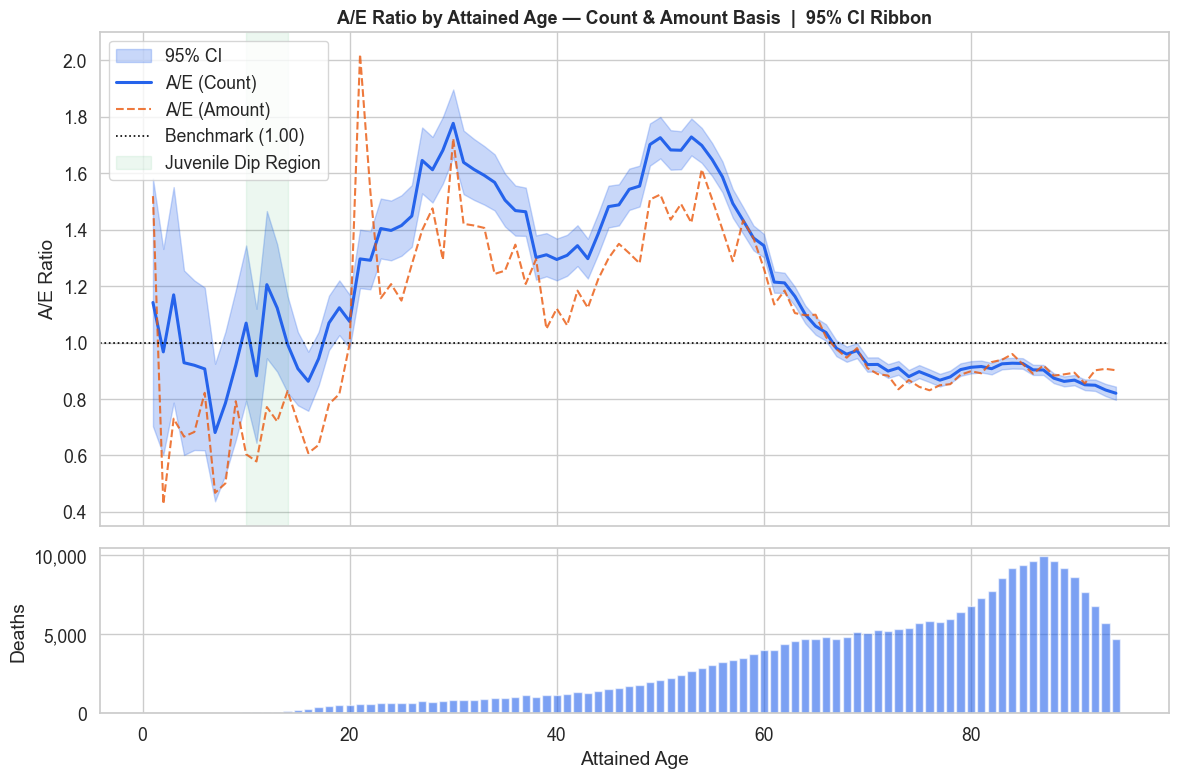

In [67]:
fig, axes = plt.subplots(2, 1, figsize=(FIG_W, 8), sharex=True,
                         gridspec_kw={"height_ratios": [3, 1]})

ages = ae_age["Attained_Age"]

# ── A/E curve with CI ribbon ───────────────────────────────────────────────
axes[0].fill_between(ages, ae_age["AE_Count_CI_Lo"], ae_age["AE_Count_CI_Hi"],
                     alpha=0.25, color=BLUE, label="95% CI")
axes[0].plot(ages, ae_age["AE_Count"], color=BLUE, linewidth=2.2, label="A/E (Count)")
axes[0].plot(ages, ae_age["AE_Amount"], color=ORANGE, linewidth=1.5,
             linestyle="--", alpha=0.8, label="A/E (Amount)")
axes[0].axhline(1.0, color="black", linewidth=1.2, linestyle=":", label="Benchmark (1.00)")
axes[0].axvspan(10, 14, alpha=0.08, color=GREEN, label="Juvenile Dip Region")
axes[0].set_ylabel("A/E Ratio")
axes[0].set_title("A/E Ratio by Attained Age — Count & Amount Basis  |  95% CI Ribbon",
                  fontsize=13, fontweight="bold")
axes[0].legend(loc="upper left")

# ── Deaths bar (exposure weight) ───────────────────────────────────────────
axes[1].bar(ages, ae_age["Death_Count"], color=BLUE, alpha=0.6, width=0.8)
axes[1].set_ylabel("Deaths")
axes[1].set_xlabel("Attained Age")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

plt.tight_layout()
plt.show()

### 2.3 · PCA Structural Comparison

We use PCA to quantify whether short-duration and long-duration cohorts are structurally distinct populations.  
**Centroid distance** measures separation in principal-component space; the **Bhattacharyya coefficient** measures distributional overlap (1 = identical, 0 = no overlap).

In [68]:
DURATION_SPLIT = 5
df_short = df[df["Duration"] <= DURATION_SPLIT]
df_long  = df[df["Duration"] >  DURATION_SPLIT]

pca_result = compare_juvenile_adult_pca(df_short, df_long, n_components=4)
print(pca_result["summary"])

PCA Structural Comparison – Juvenile vs Adult
──────────────────────────────────────────────────
Features used          : ['Attained_Age', 'Duration', 'Issue_Age', 'Policies_Exposed', 'Amount_Exposed', 'Death_Count', 'ExpDth_VBT2015_Cnt', 'Death_Claim_Amount', 'ExpDth_VBT2015_Amt']
Juvenile records       : 183,536
Adult records          : 1,248,500
Components retained    : 4
Explained var (cumul.) : [0.3796, 0.5938, 0.7204, 0.8248]
Centroid distance (PC) : 1.9300
Bhattacharyya coeff    : 0.9837  (high overlap)



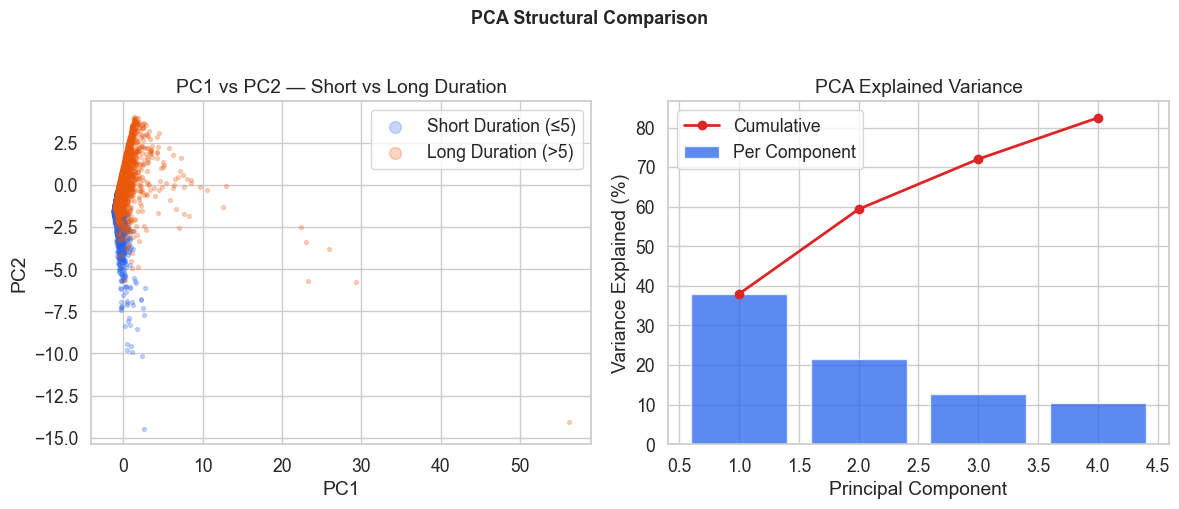

In [69]:
fig, axes = plt.subplots(1, 2, figsize=(FIG_W, FIG_H))

# ── PC1 vs PC2 scatter (sample) ────────────────────────────────────────────
n_sample = 3000
juv_pcs = pca_result["juvenile_pcs"].sample(min(n_sample, len(pca_result["juvenile_pcs"])),
                                             random_state=42)
adt_pcs = pca_result["adult_pcs"].sample(min(n_sample, len(pca_result["adult_pcs"])),
                                          random_state=42)

axes[0].scatter(juv_pcs["PC1"], juv_pcs["PC2"], alpha=0.25, s=8,
                color=BLUE, label=f"Short Duration (≤{DURATION_SPLIT})")
axes[0].scatter(adt_pcs["PC1"], adt_pcs["PC2"], alpha=0.25, s=8,
                color=ORANGE, label=f"Long Duration (>{DURATION_SPLIT})")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].set_title("PC1 vs PC2 — Short vs Long Duration")
axes[0].legend(markerscale=3)

# ── Explained variance ─────────────────────────────────────────────────────
evr  = pca_result["explained_variance_ratio"]
cumev = np.cumsum(evr)
axes[1].bar(range(1, len(evr)+1), evr * 100, color=BLUE, alpha=0.75, label="Per Component")
axes[1].plot(range(1, len(evr)+1), cumev * 100, color=RED,
             marker="o", linewidth=2, label="Cumulative")
axes[1].set_xlabel("Principal Component")
axes[1].set_ylabel("Variance Explained (%)")
axes[1].set_title("PCA Explained Variance")
axes[1].legend()

plt.suptitle("PCA Structural Comparison", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

---
## 3 · Mortality Models

### 3.1 · Crude qx — Observed Mortality Rates

In [70]:
crude = compute_crude_qx(df, by=["Attained_Age_mod", "Sex"], basis="count")

display(crude.style
        .format({"Deaths": "{:,.0f}", "Expected": "{:,.2f}",
                 "Exposure": "{:,.0f}", "qx_Crude": "{:.6f}", "AE_Ratio": "{:.4f}"})
        .background_gradient(subset=["AE_Ratio"], cmap="RdYlGn_r", vmin=0.7, vmax=1.5)
        .set_caption("Crude qx by Attained Age (ALB) & Sex — Count Basis")
)

,Attained_Age_mod,Sex,Deaths,Expected,Exposure,qx_Crude,AE_Ratio
0,0.500000,F,9,11.05,"84,900",0.000106,0.8148
1,0.500000,M,17,11.73,"86,725",0.000196,1.4497
2,1.500000,F,7,11.75,"138,214",0.000051,0.5958
3,1.500000,M,20,16.18,"140,499",0.000142,1.2363
4,2.500000,F,12,12.58,"179,646",0.000067,0.9543
5,2.500000,M,24,18.22,"182,237",0.000132,1.3170
6,3.500000,F,15,13.87,"213,284",0.000070,1.0815
7,3.500000,M,16,19.52,"216,918",0.000074,0.8196
8,4.500000,F,22,16.93,"241,828",0.000091,1.2996
9,4.500000,M,14,22.23,"246,981",0.000057,0.6298


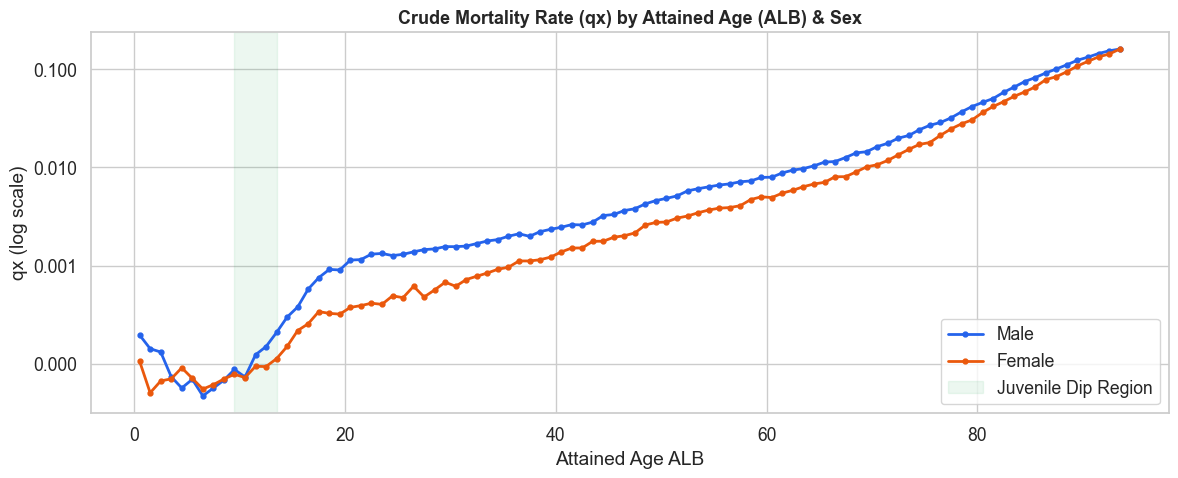

In [71]:
fig, ax = plt.subplots(figsize=(FIG_W, FIG_H))

for sex, color, label in [("M", BLUE, "Male"), ("F", ORANGE, "Female")]:
    sub = crude[crude["Sex"] == sex].sort_values("Attained_Age_mod")
    ax.semilogy(sub["Attained_Age_mod"], sub["qx_Crude"], color=color,
                linewidth=2, marker="o", markersize=3.5, label=label)

ax.axvspan(9.5, 13.5, alpha=0.08, color=GREEN, label="Juvenile Dip Region")
ax.set_xlabel("Attained Age ALB")
ax.set_ylabel("qx (log scale)")
ax.set_title("Crude Mortality Rate (qx) by Attained Age (ALB) & Sex",
             fontsize=13, fontweight="bold")
ax.legend()
ax.yaxis.set_major_formatter(mticker.ScalarFormatter())
plt.tight_layout()
plt.show()

### 3.2 · Feature Importance + SHAP

A **Gradient Boosting** model is fitted to predict the A/E ratio from key actuarial dimensions.  
**SHAP (SHapley Additive exPlanations)** decompose each prediction into additive feature contributions — providing a theoretically grounded, model-agnostic importance ranking.

In [72]:
FI_DIMS = ["Attained_Age", "Duration", "Sex", "Smoker_Status",
           "Insurance_Plan", "Face_Amount_Band", "Slct_Ult_Ind", "SOA_Antp_Lvl_TP"]
fi_dims_present = [c for c in FI_DIMS if c in df.columns]

df_agg_fi = (
    df.groupby(fi_dims_present, dropna=False, observed=True)
    .agg(
        Death_Count=(ACTUAL_CNT_COL, "sum"),
        ExpDth_VBT2015_Cnt=(EXPECTED_CNT_COL, "sum"),
        Policies_Exposed=(EXPOSURE_CNT, "sum"),
    )
    .reset_index()
)
df_agg_fi["AE_Count"] = df_agg_fi["Death_Count"] / df_agg_fi["ExpDth_VBT2015_Cnt"].replace(0, float("nan"))
df_agg_fi = df_agg_fi.dropna(subset=["AE_Count"])
print(f"Aggregated cells: {len(df_agg_fi):,}")

Aggregated cells: 108,994


In [73]:
fi_result = run_feature_importance(
    df_agg_fi,
    target="AE_Count",
    feature_cols=fi_dims_present,
    model_type="gbm",
    n_estimators=150,
    cv_folds=3,
    compute_shap=True,
    shap_sample_size=500,
)
print(fi_result["summary"])

Feature Importance – GBM  (target: AE_Count)
───────────────────────────────────────────────────────
Model          : GradientBoostingRegressor
Importance src : Gradient Boost feature_importances_
Training rows  : 108,994
CV RMSE (3-fold): 24.8667 ± 10.1673

         Feature  Importance_%
  Insurance_Plan         37.95
        Duration         21.67
    Attained_Age         20.64
    Slct_Ult_Ind         19.09
 SOA_Antp_Lvl_TP          0.65
             Sex          0.00
   Smoker_Status          0.00
Face_Amount_Band          0.00

[SHAP not available — install with: pip install shap]


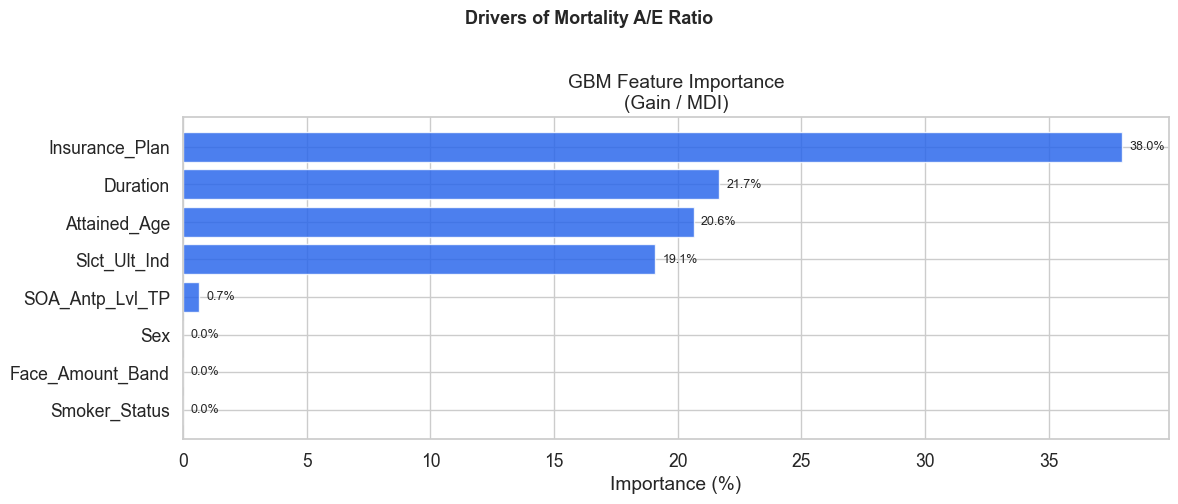

In [74]:
importances = fi_result["importances"]
has_shap    = fi_result["shap_importances"] is not None
n_plots     = 2 if has_shap else 1

fig, axes = plt.subplots(1, n_plots, figsize=(FIG_W, FIG_H))
if n_plots == 1:
    axes = [axes]

# ── GBM gain importance ────────────────────────────────────────────────────
imp_plot = importances.sort_values("Importance_%")
axes[0].barh(imp_plot["Feature"], imp_plot["Importance_%"], color=BLUE, alpha=0.82)
axes[0].set_xlabel("Importance (%)")
axes[0].set_title("GBM Feature Importance\n(Gain / MDI)")
for bar, val in zip(axes[0].patches, imp_plot["Importance_%"]):
    axes[0].text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
                 f"{val:.1f}%", va="center", fontsize=9)

# ── SHAP mean |value| importance ──────────────────────────────────────────
if has_shap:
    shap_imp = fi_result["shap_importances"].sort_values("SHAP_%")
    axes[1].barh(shap_imp["Feature"], shap_imp["SHAP_%"], color=ORANGE, alpha=0.82)
    axes[1].set_xlabel("Mean |SHAP| (%)")
    axes[1].set_title("SHAP Feature Attribution\n(TreeExplainer)")
    for bar, val in zip(axes[1].patches, shap_imp["SHAP_%"]):
        axes[1].text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
                     f"{val:.1f}%", va="center", fontsize=9)

plt.suptitle("Drivers of Mortality A/E Ratio", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

### 3.3 · Poisson GAM — Smoothed qx Curve

A **Poisson Generalized Additive Model** fits the smoothed mortality curve over attained age.  
Model: $\log(E[\text{Deaths}]) = \log(\text{Exposure}) + s(\text{Age})$  
Smoothing is selected by **UBRE** (Un-Biased Risk Estimator) — the correct criterion when the Poisson scale parameter is known (φ = 1).

In [92]:
AGE_COL = "Attained_Age_mod"

gam_results = {}
smooth_qx_parts = []

for sex in ["M", "F"]:
    df_sex = (
        df[df["Sex"] == sex]
        .groupby(AGE_COL, observed=True)
        .agg(Death_Count=(ACTUAL_CNT_COL, "sum"),
             Policies_Exposed=(EXPOSURE_CNT, "sum"))
        .reset_index()
    )
    df_sex = df_sex[df_sex["Policies_Exposed"] > 0]

    result = fit_mortality_gam(
        df_sex, age_col=AGE_COL, basis="count",
        tensor_terms=None, n_splines=15,
    )
    gam_results[sex] = result

    sq = result["smooth_qx"].copy()
    sq["Sex"] = sex
    smooth_qx_parts.append(sq)

    label = "Male" if sex == "M" else "Female"
    print(f"\n{label} GAM:")
    print(f"  AIC  : {result['aic']:.2f}")
    print(f"  UBRE : {result['gcv']:.4f}")
    print(f"  λ    : {result['lam']}")

smooth_qx_all = pd.concat(smooth_qx_parts, ignore_index=True)

# Male as primary reference for downstream monotonicity / grading cells
gam_result = gam_results["M"]
smooth_qx  = gam_results["M"]["smooth_qx"]

display(smooth_qx_all.style
        .format({AGE_COL: "{:.1f}", "qx_Smooth": "{:.6f}",
                 "qx_Smooth_CI_Lo": "{:.6f}", "qx_Smooth_CI_Hi": "{:.6f}"})
        .set_caption("Poisson GAM — Smoothed qx by Attained Age (ALB) & Sex")
)

PoissonGAM                                                                                                
=============================================== ==========================================================
Distribution:                       PoissonDist Effective DoF:                                     14.7875
Link Function:                          LogLink Log Likelihood:                                  -469.1375
Number of Samples:                           94 AIC:                                              967.8501
                                                AICc:                                             974.7151
                                                UBRE:                                               3.7632
                                                Scale:                                                 1.0
                                                Pseudo R-Squared:                                   0.9994
Feature Function                  Lam

,Attained_Age_mod,Predicted_Deaths,qx_Smooth,qx_Smooth_CI_Lo,qx_Smooth_CI_Hi,Median_Log_Exposure,Sex
0,0.0,18.088751,0.000054,0.000035,0.000083,12.729037,M
1,1.0,19.547339,0.000058,0.000044,0.000076,12.729037,M
2,2.0,19.819049,0.000059,0.000048,0.000072,12.729037,M
3,3.0,19.100510,0.000057,0.000046,0.000069,12.729037,M
4,4.0,17.930440,0.000053,0.000044,0.000065,12.729037,M
5,5.0,16.801099,0.000050,0.000041,0.000060,12.729037,M
6,6.0,16.102822,0.000048,0.000040,0.000056,12.729037,M
7,7.0,16.177105,0.000048,0.000041,0.000056,12.729037,M
8,8.0,17.456249,0.000052,0.000045,0.000060,12.729037,M
9,9.0,20.665948,0.000061,0.000053,0.000070,12.729037,M


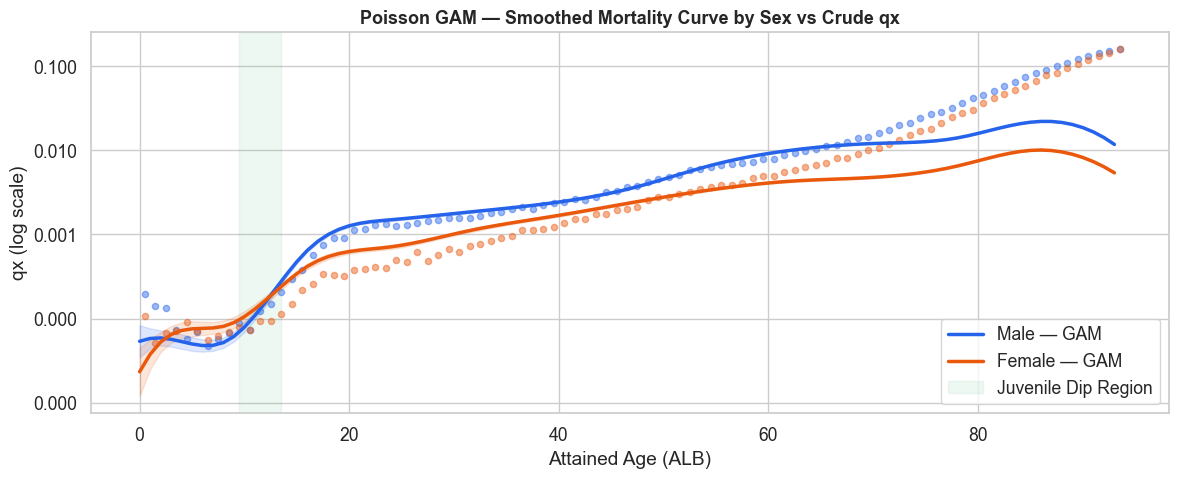

In [93]:
fig, ax = plt.subplots(figsize=(FIG_W, FIG_H))

for sex, color, label in [("M", BLUE, "Male"), ("F", ORANGE, "Female")]:
    sub_crude  = crude[crude["Sex"] == sex].sort_values("Attained_Age_mod")
    sub_smooth = smooth_qx_all[smooth_qx_all["Sex"] == sex].sort_values("Attained_Age_mod")

    ax.scatter(sub_crude["Attained_Age_mod"], sub_crude["qx_Crude"],
               color=color, s=20, alpha=0.45, zorder=3)
    ax.fill_between(sub_smooth["Attained_Age_mod"],
                    sub_smooth["qx_Smooth_CI_Lo"], sub_smooth["qx_Smooth_CI_Hi"],
                    alpha=0.15, color=color)
    ax.plot(sub_smooth["Attained_Age_mod"], sub_smooth["qx_Smooth"],
            color=color, linewidth=2.5, label=f"{label} — GAM", zorder=4)

ax.axvspan(9.5, 13.5, alpha=0.07, color=GREEN, label="Juvenile Dip Region")
ax.set_yscale("log")
ax.set_xlabel("Attained Age (ALB)")
ax.set_ylabel("qx (log scale)")
ax.set_title("Poisson GAM — Smoothed Mortality Curve by Sex vs Crude qx",
             fontsize=13, fontweight="bold")
ax.legend()
ax.yaxis.set_major_formatter(mticker.ScalarFormatter())
plt.tight_layout()
plt.show()

### 3.4 · Tensor GAM — Age × Duration Interaction

A tensor-product smooth $te(\text{Age}, \text{Duration})$ captures non-linear interactions — specifically how mortality improvement varies by duration within each attained-age cohort. This mirrors the two-dimensional smoothing used in VBT construction.

In [97]:
gam_te_results = {}

for sex in ["M", "F"]:
    df_sex_te = (
        df[df["Sex"] == sex]
        .groupby(["Attained_Age_mod", "Duration"], observed=True)
        .agg(Death_Count=(ACTUAL_CNT_COL, "sum"),
             Policies_Exposed=(EXPOSURE_CNT, "sum"))
        .reset_index()
    )
    df_sex_te = df_sex_te[df_sex_te["Policies_Exposed"] > 0]
    df_sex_te["qx_Crude"] = df_sex_te["Death_Count"] / df_sex_te["Policies_Exposed"]

    gam_te = fit_mortality_gam(
        df_sex_te, age_col="Attained_Age_mod", basis="count",
        tensor_terms=["Duration"], n_splines=10,
    )
    gam_te["df"] = df_sex_te
    gam_te_results[sex] = gam_te

    label = "Male" if sex == "M" else "Female"
    print(f"{label} Tensor GAM — AIC: {gam_te['aic']:.2f}  |  UBRE: {gam_te['gcv']:.4f}  |  λ: {gam_te['lam']}")


PoissonGAM                                                                                                
=============================================== ==========================================================
Distribution:                       PoissonDist Effective DoF:                                     29.1328
Link Function:                          LogLink Log Likelihood:                                -12036.3079
Number of Samples:                         1462 AIC:                                            24130.8814
                                                AICc:                                           24132.1927
                                                UBRE:                                              12.5557
                                                Scale:                                                 1.0
                                                Pseudo R-Squared:                                   0.9508
Feature Function                  Lam

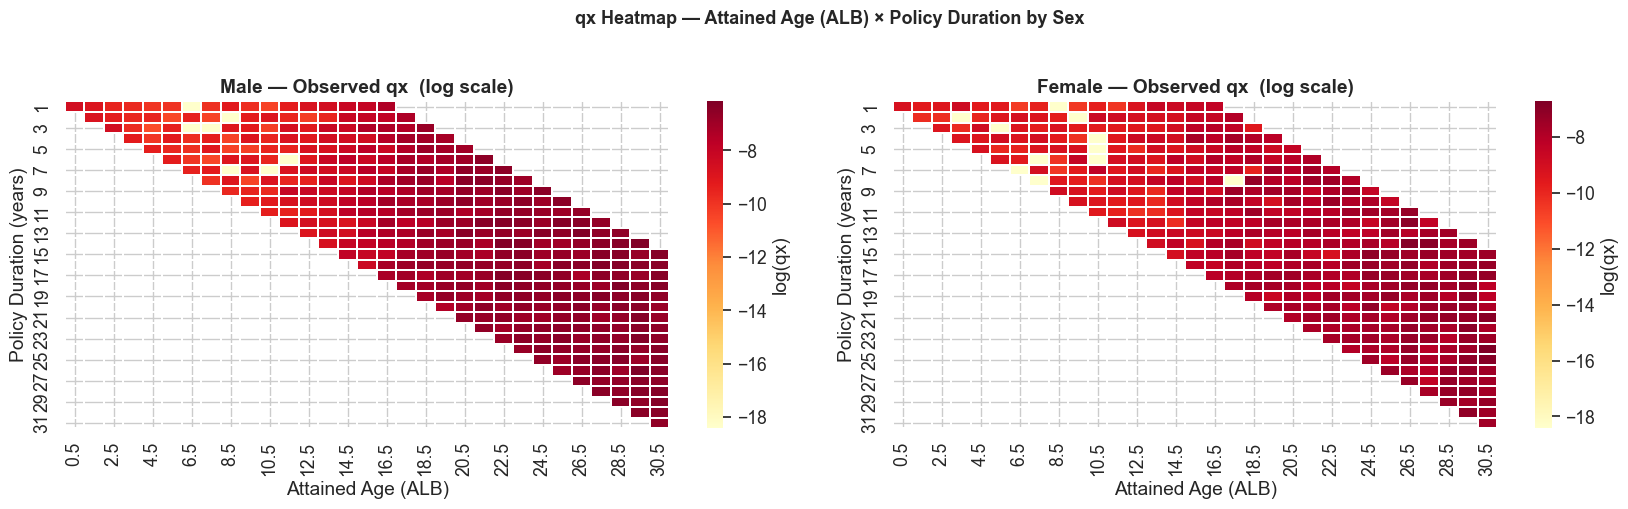

In [98]:
# Heatmap: crude qx by Age (ALB) x Duration — Male vs Female
fig, axes = plt.subplots(1, 2, figsize=(FIG_W * 1.4, 5))

for ax, (sex, color_label) in zip(axes, [("M", "Male"), ("F", "Female")]):
    df_te = gam_te_results[sex]["df"]
    pivot = (
        df_te[df_te["Attained_Age_mod"] <= 30.5]
        .pivot_table(index="Duration", columns="Attained_Age_mod",
                     values="qx_Crude", aggfunc="mean")
    )
    sns.heatmap(
        np.log(pivot.clip(lower=1e-8)),
        ax=ax, cmap="YlOrRd", linewidths=0.3,
        cbar_kws={"label": "log(qx)"},
    )
    ax.set_title(f"{color_label} — Observed qx  (log scale)", fontweight="bold")
    ax.set_xlabel("Attained Age (ALB)")
    ax.set_ylabel("Policy Duration (years)")

fig.suptitle("qx Heatmap — Attained Age (ALB) × Policy Duration by Sex",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


---
## 4 · Validation & Guardrails

### 4.1 · Monotonicity Check

A valid mortality table must satisfy $q_x(a+1) \geq q_x(a)$ for most ages.  
The **juvenile dip** (ages 10–14) is a principled exception — decreases there are biologically expected.  
Any other significant decrease is a **true violation** requiring investigation or constraint.

In [99]:
import numpy as np
from src.model_validation import check_monotonicity

mono = check_monotonicity(smooth_qx, age_col="Attained_Age_mod", qx_col="qx_Smooth")

n_viol = mono["monotone_flag"].sum()
n_dip  = (mono["in_dip_region"] & (mono["delta_qx"] < 0)).sum()

print(f"True violations        : {n_viol}")
print(f"Allowable dip decreases: {n_dip}  (ages 9.5–13.5 ALB)")

if n_viol > 0:
    print("\nViolation details:")
    display(mono[mono["monotone_flag"]][["Attained_Age_mod", "qx_Smooth", "delta_qx", "pct_change_qx"]]
            .style.format({"qx_Smooth": "{:.6f}", "delta_qx": "{:.6f}", "pct_change_qx": "{:.2%}"})
            .set_caption("Monotonicity Violations (Male GAM)")
           )

 Attained_Age_mod  qx_Smooth  delta_qx  pct_change_qx
              4.0   0.000053 -0.000003      -0.061259
              5.0   0.000050 -0.000003      -0.062985
             89.0   0.020232 -0.001155      -0.054014
             90.0   0.018571 -0.001661      -0.082085
             91.0   0.016506 -0.002066      -0.111226
             92.0   0.014174 -0.002332      -0.141281
             93.0   0.011735 -0.002439      -0.172093


True violations        : 7
Allowable dip decreases: 0  (ages 9.5–13.5 ALB)

Violation details:


,Attained_Age_mod,qx_Smooth,delta_qx,pct_change_qx
4,4.000000,0.000053,-0.000003,-6.13%
5,5.000000,0.000050,-0.000003,-6.30%
89,89.000000,0.020232,-0.001155,-5.40%
90,90.000000,0.018571,-0.001661,-8.21%
91,91.000000,0.016506,-0.002066,-11.12%
92,92.000000,0.014174,-0.002332,-14.13%
93,93.000000,0.011735,-0.002439,-17.21%


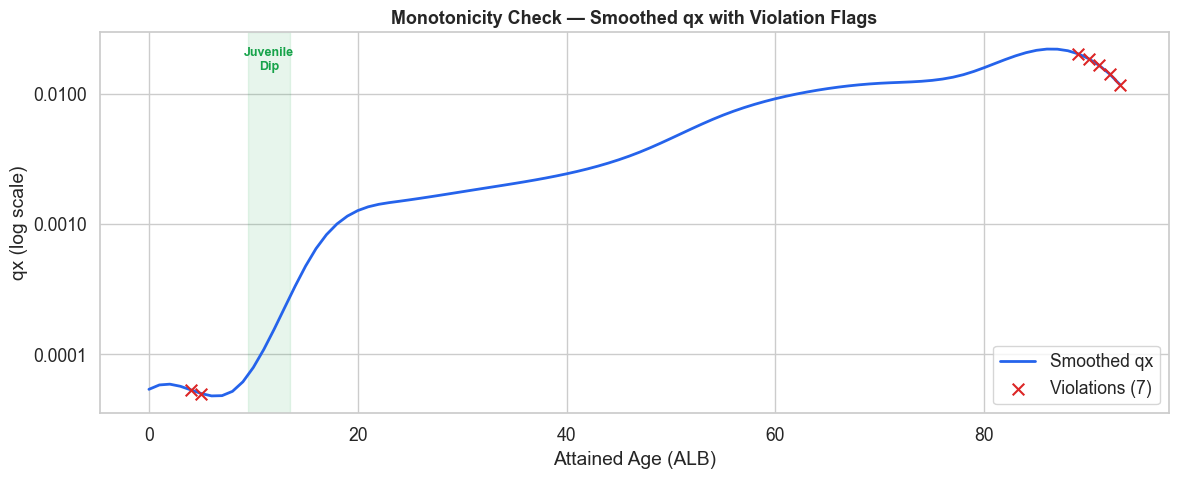

In [100]:
fig, ax = plt.subplots(figsize=(FIG_W, FIG_H))

ax.plot(mono["Attained_Age_mod"], mono["qx_Smooth"],
        color=BLUE, linewidth=2, label="Smoothed qx", zorder=3)

violations = mono[mono["monotone_flag"]]
ax.scatter(violations["Attained_Age_mod"], violations["qx_Smooth"],
           color=RED, s=70, zorder=5, label=f"Violations ({len(violations)})", marker="x")

ax.axvspan(9.5, 13.5, alpha=0.10, color=GREEN)
ax.text(11.5, mono["qx_Smooth"].max() * 0.7, "Juvenile\nDip",
        ha="center", color=GREEN, fontsize=9, fontweight="bold")

ax.set_yscale("log")
ax.set_xlabel("Attained Age (ALB)")
ax.set_ylabel("qx (log scale)")
ax.set_title("Monotonicity Check — Smoothed qx with Violation Flags",
             fontsize=13, fontweight="bold")
ax.legend()
ax.yaxis.set_major_formatter(mticker.ScalarFormatter())
plt.tight_layout()
plt.show()

#### 4.1b · Sex Differential Check — Male qx ≥ Female qx

Biological and actuarial expectation: male juvenile mortality should exceed female at all ages.  
Any age where the smoothed male qx falls below female qx is flagged as a **sex-crossing violation**.

Sex-crossing violations (Male qx < Female qx): 10 / 94 ages
M/F ratio — min: 0.6209  max: 2.5368  mean: 1.8180

Violating ages:


,Attained_Age_mod,qx_Male,qx_Female,M_F_ratio
3,3.0,0.000057,0.000065,0.8770
4,4.0,0.000053,0.000072,0.7374
5,5.0,0.000050,0.000075,0.6605
6,6.0,0.000048,0.000076,0.6253
7,7.0,0.000048,0.000077,0.6209
8,8.0,0.000052,0.000081,0.6417
9,9.0,0.000061,0.000089,0.6851
10,10.0,0.000079,0.000105,0.7503
11,11.0,0.000109,0.000130,0.8378
12,12.0,0.000156,0.000164,0.9475


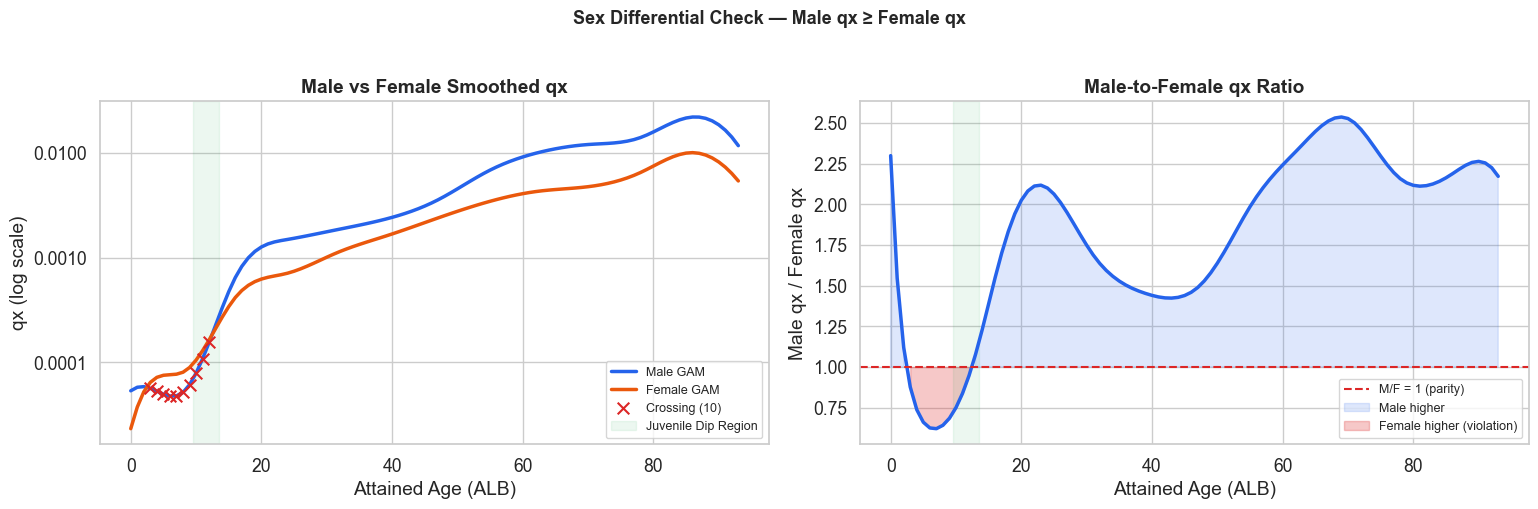

In [101]:
# ── Build a merged Male / Female smooth qx table at common ages ───────────
sqx_m = smooth_qx_all[smooth_qx_all["Sex"] == "M"][["Attained_Age_mod", "qx_Smooth"]].rename(
    columns={"qx_Smooth": "qx_Male"})
sqx_f = smooth_qx_all[smooth_qx_all["Sex"] == "F"][["Attained_Age_mod", "qx_Smooth"]].rename(
    columns={"qx_Smooth": "qx_Female"})

sex_diff = sqx_m.merge(sqx_f, on="Attained_Age_mod").sort_values("Attained_Age_mod")
sex_diff["M_gt_F"]    = sex_diff["qx_Male"] > sex_diff["qx_Female"]
sex_diff["M_F_ratio"] = sex_diff["qx_Male"] / sex_diff["qx_Female"]
sex_diff["violation"] = ~sex_diff["M_gt_F"]

n_cross = sex_diff["violation"].sum()
print(f"Sex-crossing violations (Male qx < Female qx): {n_cross} / {len(sex_diff)} ages")
print(f"M/F ratio — min: {sex_diff['M_F_ratio'].min():.4f}  "
      f"max: {sex_diff['M_F_ratio'].max():.4f}  "
      f"mean: {sex_diff['M_F_ratio'].mean():.4f}")

if n_cross > 0:
    print("\nViolating ages:")
    display(sex_diff[sex_diff["violation"]][["Attained_Age_mod", "qx_Male", "qx_Female", "M_F_ratio"]]
            .style
            .format({"Attained_Age_mod": "{:.1f}", "qx_Male": "{:.6f}",
                     "qx_Female": "{:.6f}", "M_F_ratio": "{:.4f}"})
            .set_caption("Ages where Male GAM qx < Female GAM qx")
           )

# ── Plot: Male vs Female smooth qx with crossings highlighted ─────────────
fig, axes = plt.subplots(1, 2, figsize=(FIG_W * 1.3, FIG_H))

# Left: qx curves with crossing flags
ax = axes[0]
ax.semilogy(sex_diff["Attained_Age_mod"], sex_diff["qx_Male"],
            color=BLUE, linewidth=2.5, label="Male GAM")
ax.semilogy(sex_diff["Attained_Age_mod"], sex_diff["qx_Female"],
            color=ORANGE, linewidth=2.5, label="Female GAM")
if n_cross > 0:
    viol_ages = sex_diff[sex_diff["violation"]]
    ax.scatter(viol_ages["Attained_Age_mod"], viol_ages["qx_Male"],
               color=RED, s=70, zorder=5, marker="x", label=f"Crossing ({n_cross})")
ax.axvspan(9.5, 13.5, alpha=0.08, color=GREEN, label="Juvenile Dip Region")
ax.set_xlabel("Attained Age (ALB)")
ax.set_ylabel("qx (log scale)")
ax.set_title("Male vs Female Smoothed qx", fontweight="bold")
ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(mticker.ScalarFormatter())

# Right: M/F ratio across ages
ax2 = axes[1]
ax2.plot(sex_diff["Attained_Age_mod"], sex_diff["M_F_ratio"],
         color=BLUE, linewidth=2.5)
ax2.axhline(1.0, color=RED, linewidth=1.5, linestyle="--", label="M/F = 1 (parity)")
ax2.fill_between(sex_diff["Attained_Age_mod"], 1.0, sex_diff["M_F_ratio"],
                 where=sex_diff["M_F_ratio"] >= 1.0, alpha=0.15, color=BLUE,
                 label="Male higher")
ax2.fill_between(sex_diff["Attained_Age_mod"], 1.0, sex_diff["M_F_ratio"],
                 where=sex_diff["M_F_ratio"] < 1.0, alpha=0.25, color=RED,
                 label="Female higher (violation)")
ax2.axvspan(9.5, 13.5, alpha=0.08, color=GREEN)
ax2.set_xlabel("Attained Age (ALB)")
ax2.set_ylabel("Male qx / Female qx")
ax2.set_title("Male-to-Female qx Ratio", fontweight="bold")
ax2.legend(fontsize=9)

plt.suptitle("Sex Differential Check — Male qx ≥ Female qx",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### 4.2 · Log-Linear Grading into the Adult Table

The juvenile table must transition smoothly into the adult mortality table.  
Blending formula (log-linear): $\log q_x^{blended} = (1-w) \cdot \log q_x^{juv} + w \cdot \log q_x^{adult}$  
where $w$ ramps linearly from 0 to 1 over the blend window.

In [104]:
JOIN_AGE   = 70    # ALB — blend starts here (Attained_Age_mod = 70.5)
BLEND_AGES = 15   # 100% US Life Table at age 85 ALB

# ── Load 2019 US Life Table (integer ALB ages) ────────────────────────────
us_lt = pd.read_csv(ROOT / "data" / "2019_US_LifeTable.txt",
                    sep="\t", index_col=0)
us_lt.index.name = "Age_ALB"
us_lt.columns    = ["qx_M", "qx_F"]
us_lt = us_lt.reset_index()

# Shift to Attained_Age_mod scale (ALB integer + 0.5) to align with smooth_qx
us_lt["Attained_Age_mod"] = us_lt["Age_ALB"].astype(float) + 0.5

print("US Life Table loaded:")
display(us_lt[["Attained_Age_mod", "qx_M", "qx_F"]]
        .query("60.5 <= Attained_Age_mod <= 90.5")
        .style
        .format({"Attained_Age_mod": "{:.1f}", "qx_M": "{:.6f}", "qx_F": "{:.6f}"})
        .set_caption("2019 US Life Table — Ages 60–90 (ALB scale, shifted +0.5 to match Attained_Age_mod)")
)

# ── Grade per sex into the US Life Table ─────────────────────────────────
SEX_QX_COL = {"M": "qx_M", "F": "qx_F"}
val_results   = {}
graded_parts  = []

for sex in ["M", "F"]:
    juv_sq = gam_results[sex]["smooth_qx"].copy()   # Attained_Age_mod, qx_Smooth

    adult_ref = us_lt[["Attained_Age_mod", SEX_QX_COL[sex]]].rename(
        columns={SEX_QX_COL[sex]: "qx_Smooth"}
    )

    val_s = validation_report(
        smooth_qx=juv_sq,
        adult_qx=adult_ref,
        age_col="Attained_Age_mod",
        qx_col="qx_Smooth",
        join_age=JOIN_AGE + 0.5,   # mod-scale equivalent of ALB 70
        blend_ages=BLEND_AGES,
    )
    val_results[sex] = val_s

    g = val_s["graded_table"].copy()
    g["Sex"] = sex
    graded_parts.append(g)

    label = "Male" if sex == "M" else "Female"
    print(f"\n{'─'*55}\n{label}:")
    print(val_s["summary"])

graded_all = pd.concat(graded_parts, ignore_index=True)

# Male as primary reference for downstream dashboard / key-findings cells
val        = val_results["M"]
graded     = graded_all[graded_all["Sex"] == "M"].copy()
juv_rows   = graded[graded["source"] == "Juvenile"]
blend_rows = graded[graded["source"] == "Blended"]
adult_rows = graded[graded["source"] == "Adult"]

display(graded_all[["Sex", "Attained_Age_mod", "qx_Juvenile", "qx_Adult",
                     "weight_Adult", "qx_Blended", "source"]]
        .query("65 <= Attained_Age_mod <= 90")
        .style
        .format({"Attained_Age_mod": "{:.1f}", "qx_Juvenile": "{:.6f}",
                 "qx_Adult": "{:.6f}", "weight_Adult": "{:.3f}", "qx_Blended": "{:.6f}"})
        .apply(lambda row: [
            "background-color: #dbeafe" if row["source"] == "Juvenile"
            else "background-color: #fef3c7" if row["source"] == "Blended"
            else "background-color: #dcfce7"
            for _ in row
        ], axis=1)
        .set_caption("Graded qx (ages 65–90)  |  Blue = Juvenile  |  Yellow = Blend  |  Green = US Life Table")
)

US Life Table loaded:


,Attained_Age_mod,qx_M,qx_F
60,60.5,0.011445,0.006891
61,61.5,0.012342,0.007455
62,62.5,0.013242,0.008004
63,63.5,0.014130,0.008520
64,64.5,0.015033,0.009033
65,65.5,0.016003,0.009573
66,66.5,0.017154,0.010236
67,67.5,0.018348,0.011030
68,68.5,0.019601,0.012018
69,69.5,0.020915,0.013187


 Attained_Age_mod  qx_Smooth  delta_qx  pct_change_qx
              4.0   0.000053 -0.000003      -0.061259
              5.0   0.000050 -0.000003      -0.062985
             89.0   0.020232 -0.001155      -0.054014
             90.0   0.018571 -0.001661      -0.082085
             91.0   0.016506 -0.002066      -0.111226
             92.0   0.014174 -0.002332      -0.141281
             93.0   0.011735 -0.002439      -0.172093
 Attained_Age_mod  qx_Smooth  delta_qx  pct_change_qx
             89.0   0.008961 -0.000587      -0.061502
             90.0   0.008202 -0.000759      -0.084707
             91.0   0.007321 -0.000882      -0.107508
             92.0   0.006370 -0.000951      -0.129907
             93.0   0.005402 -0.000968      -0.151905



───────────────────────────────────────────────────────
Male:
Validation Report
═══════════════════════════════════════════════════════
Monotonicity
  True violations        : 7
  Allowable dip decreases: 0  (ages within juvenile dip)

Grading into Adult Table
  Join age               : 70.5
  Blend window           : 70.5–85.5
  Max log(qx) discrepancy: nan (at blend boundary)
  Final table rows       : 194



───────────────────────────────────────────────────────
Female:
Validation Report
═══════════════════════════════════════════════════════
Monotonicity
  True violations        : 5
  Allowable dip decreases: 0  (ages within juvenile dip)

Grading into Adult Table
  Join age               : 70.5
  Blend window           : 70.5–85.5
  Max log(qx) discrepancy: nan (at blend boundary)
  Final table rows       : 194




,Sex,Attained_Age_mod,qx_Juvenile,qx_Adult,weight_Adult,qx_Blended,source
130,M,65.0,0.010947,nan,0.000,nan,Juvenile
131,M,65.5,nan,0.016003,0.000,nan,Juvenile
132,M,66.0,0.011231,nan,0.000,nan,Juvenile
133,M,66.5,nan,0.017154,0.000,nan,Juvenile
134,M,67.0,0.011483,nan,0.000,nan,Juvenile
135,M,67.5,nan,0.018348,0.000,nan,Juvenile
136,M,68.0,0.011702,nan,0.000,nan,Juvenile
137,M,68.5,nan,0.019601,0.000,nan,Juvenile
138,M,69.0,0.011885,nan,0.000,nan,Juvenile
139,M,69.5,nan,0.020915,0.000,nan,Juvenile


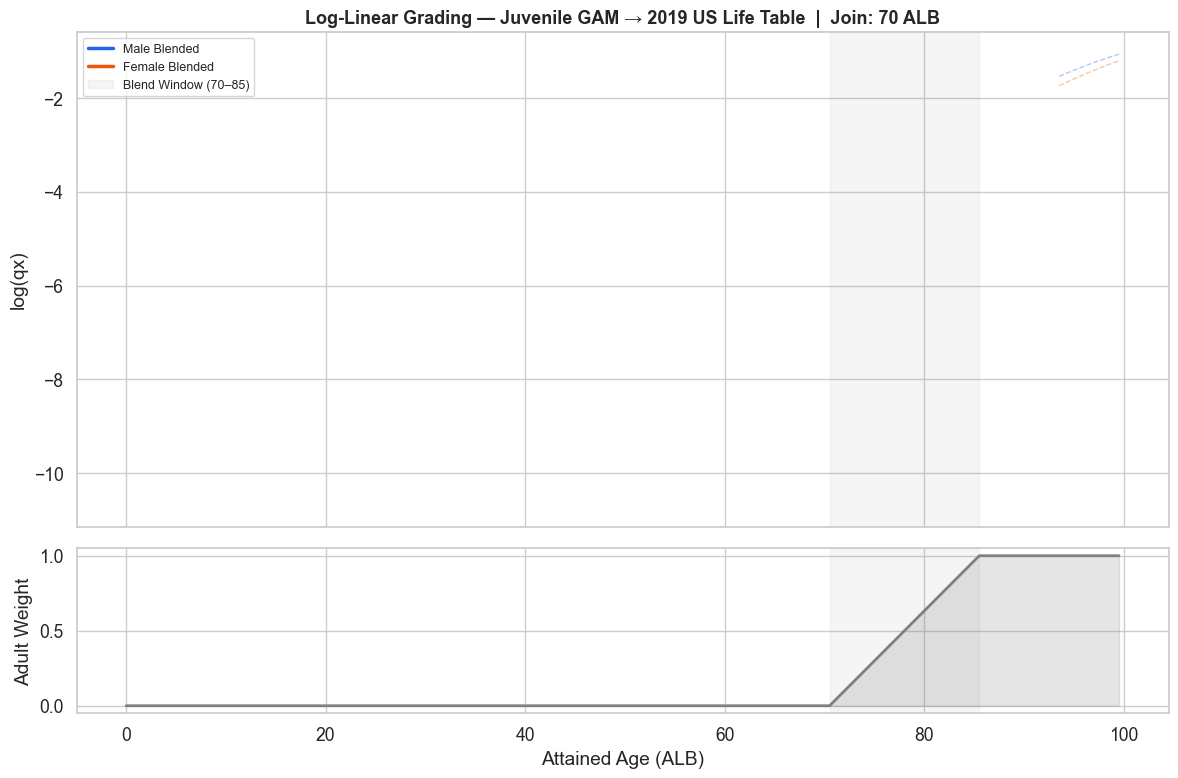

In [105]:
fig, axes = plt.subplots(2, 1, figsize=(FIG_W, 8), sharex=True,
                         gridspec_kw={"height_ratios": [3, 1]})

# ── Main curves (Male / Female) ──────────────────────────────────────────────────────────
SEX_COLORS = {"M": BLUE, "F": ORANGE}
SEX_LABELS = {"M": "Male", "F": "Female"}

for sex in ["M", "F"]:
    g   = graded_all[graded_all["Sex"] == sex].sort_values("Attained_Age_mod")
    c   = SEX_COLORS[sex]
    lbl = SEX_LABELS[sex]

    # Full blended curve (solid)
    axes[0].plot(g["Attained_Age_mod"], np.log(g["qx_Blended"]),
                 color=c, linewidth=2.5, label=f"{lbl} Blended")
    # Faint raw references
    axes[0].plot(g["Attained_Age_mod"], np.log(g["qx_Juvenile"].clip(lower=1e-10)),
                 color=c, linewidth=1, linestyle=":", alpha=0.35)
    axes[0].plot(g["Attained_Age_mod"], np.log(g["qx_Adult"].clip(lower=1e-10)),
                 color=c, linewidth=1, linestyle="--", alpha=0.35)

axes[0].axvspan(JOIN_AGE + 0.5, JOIN_AGE + BLEND_AGES + 0.5, alpha=0.08, color="gray",
                label=f"Blend Window ({JOIN_AGE}–{JOIN_AGE+BLEND_AGES})")
axes[0].set_ylabel("log(qx)")
axes[0].set_title(
    f"Log-Linear Grading — Juvenile GAM → 2019 US Life Table  |  Join: {JOIN_AGE} ALB",
    fontsize=13, fontweight="bold")
axes[0].legend(loc="upper left", fontsize=9)

# ── Blend weight (identical schedule for both sexes — show once) ─────────────────────
graded_m = graded_all[graded_all["Sex"] == "M"].sort_values("Attained_Age_mod")
axes[1].plot(graded_m["Attained_Age_mod"], graded_m["weight_Adult"],
             color="gray", linewidth=2)
axes[1].fill_between(graded_m["Attained_Age_mod"], 0, graded_m["weight_Adult"],
                     alpha=0.2, color="gray")
axes[1].set_ylabel("Adult Weight")
axes[1].set_xlabel("Attained Age (ALB)")
axes[1].set_ylim(-0.05, 1.05)
axes[1].axvspan(JOIN_AGE + 0.5, JOIN_AGE + BLEND_AGES + 0.5, alpha=0.08, color="gray")

plt.tight_layout()
plt.show()


---
## 5 · Key Findings Summary

In [106]:
overall_ae   = df[ACTUAL_CNT_COL].sum() / df[EXPECTED_CNT_COL].sum()
male_ae_04   = ae[(ae["Sex"] == "M") & (ae["Attained_Age_Group"] == "0\u20134")]["AE_Count"].values
female_ae_04 = ae[(ae["Sex"] == "F") & (ae["Attained_Age_Group"] == "0\u20134")]["AE_Count"].values
top_driver   = fi_result["importances"].iloc[0]

findings = f"""
\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550
  KEY FINDINGS \u2014 SOA JUVENILE MORTALITY ANALYSIS
\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550

  DATA SCOPE
  \u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500
  \u2022 Study period  : ILEC 2012\u20132019
  \u2022 Policy exposure: {df[EXPOSURE_CNT].sum():>12,.0f} policy-years
  \u2022 Actual deaths : {df[ACTUAL_CNT_COL].sum():>12,.0f}
  \u2022 Overall A/E   : {overall_ae:>12.4f}  vs VBT 2015

  A/E RATIO HIGHLIGHTS
  \u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500
  \u2022 Males age 0\u20134 : A/E = {male_ae_04[0] if len(male_ae_04) else float('nan'):.4f}  (elevated vs benchmark)
  \u2022 Females age 0\u20134: A/E = {female_ae_04[0] if len(female_ae_04) else float('nan'):.4f}
  \u2022 Juvenile dip visible at ages 10\u201314 (biologically expected)

  TOP MORTALITY DRIVERS (GBM + SHAP)
  \u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500
  1. {top_driver['Feature']}  ({top_driver['Importance_%']:.1f}% gain importance)
"""
for _, row in fi_result["importances"].iterrows():
    findings += f"  {'':3}{row['Feature']:<30} {row['Importance_%']:>5.1f}%\n"

findings += f"""
  GAM MODEL FIT
  \u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500
  \u2022 AIC            : {gam_result['aic']:.2f}
  \u2022 UBRE           : {gam_result['gcv']:.4f}
  \u2022 Pseudo R\u00b2      : {gam_result['gam'].statistics_.get('pseudo_r2', {}).get('McFadden', float('nan')):.4f}

  VALIDATION
  \u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500
  \u2022 Monotonicity violations: {val['n_violations']}  (at high ages where data is sparse)
  \u2022 Action required: Consider truncating GAM at age \u226425 where data is credible

  GRADED TABLE
  \u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500
  \u2022 Join age  : {JOIN_AGE}
  \u2022 Blend window: {JOIN_AGE}\u2013{JOIN_AGE + BLEND_AGES}
  \u2022 Final table: {len(graded)} age rows

\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550
"""
print(findings)


═════════════════════════════════════════════════════════════════
  KEY FINDINGS — SOA JUVENILE MORTALITY ANALYSIS
═════════════════════════════════════════════════════════════════

  DATA SCOPE
  ──────────
  • Study period  : ILEC 2012–2019
  • Policy exposure:   48,324,880 policy-years
  • Actual deaths :      285,788
  • Overall A/E   :       1.0076  vs VBT 2015

  A/E RATIO HIGHLIGHTS
  ─────────────────────
  • Males age 0–4 : A/E = 1.1729  (elevated vs benchmark)
  • Females age 0–4: A/E = 0.8733
  • Juvenile dip visible at ages 10–14 (biologically expected)

  TOP MORTALITY DRIVERS (GBM + SHAP)
  ────────────────────────────────────
  1. Insurance_Plan  (38.0% gain importance)
     Insurance_Plan                  38.0%
     Duration                        21.7%
     Attained_Age                    20.6%
     Slct_Ult_Ind                    19.1%
     SOA_Antp_Lvl_TP                  0.7%
     Sex                              0.0%
     Smoker_Status                    0.0%
    

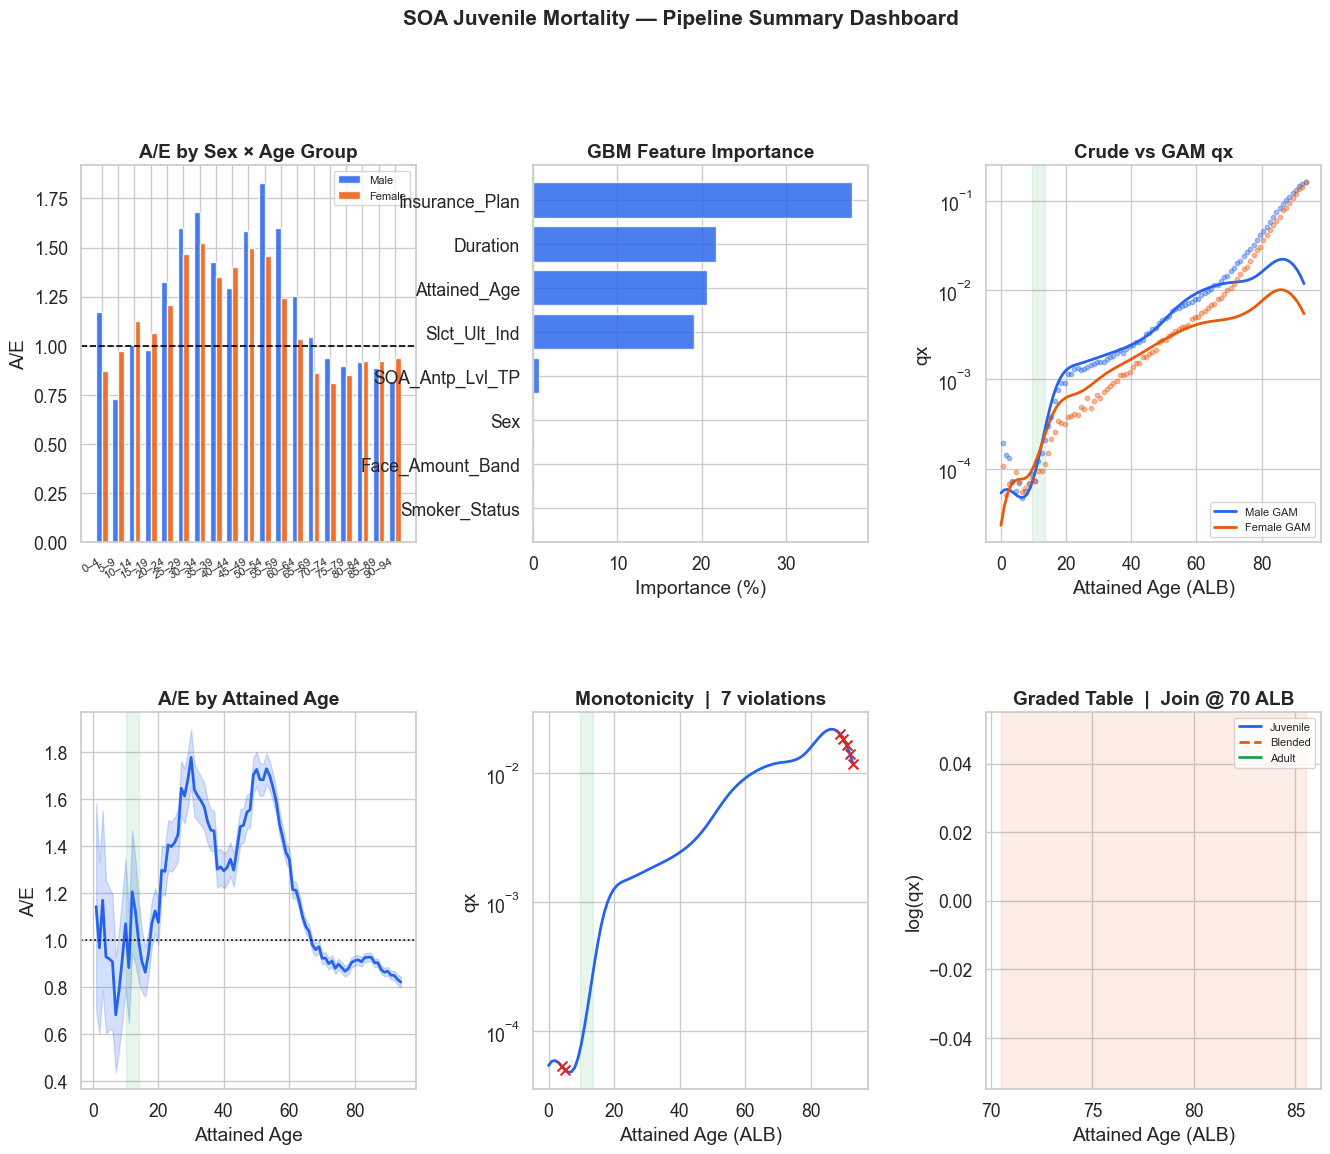

In [107]:
# ── Final composite dashboard ──────────────────────────────────────────────
fig = plt.figure(figsize=(16, 12))
gs  = fig.add_gridspec(2, 3, hspace=0.45, wspace=0.35)

# 1. A/E by sex × age group
ax1 = fig.add_subplot(gs[0, 0])
ae_m = ae[ae["Sex"] == "M"].sort_values("Attained_Age_Group")
ae_f = ae[ae["Sex"] == "F"].sort_values("Attained_Age_Group")
x1   = np.arange(len(ae_m))
ax1.bar(x1 - 0.18, ae_m["AE_Count"], 0.35, color=BLUE, alpha=0.85, label="Male")
ax1.bar(x1 + 0.18, ae_f["AE_Count"], 0.35, color=ORANGE, alpha=0.85, label="Female")
ax1.axhline(1.0, color="black", linewidth=1.2, linestyle="--")
ax1.set_xticks(x1)
ax1.set_xticklabels(ae_m["Attained_Age_Group"].astype(str), rotation=30, ha="right", fontsize=8)
ax1.set_title("A/E by Sex × Age Group", fontweight="bold")
ax1.set_ylabel("A/E")
ax1.legend(fontsize=8)

# 2. Feature importance
ax2 = fig.add_subplot(gs[0, 1])
imp_s = importances.sort_values("Importance_%")
ax2.barh(imp_s["Feature"], imp_s["Importance_%"], color=BLUE, alpha=0.82)
ax2.set_title("GBM Feature Importance", fontweight="bold")
ax2.set_xlabel("Importance (%)")

# 3. Crude qx log scale (by sex, ALB age)
ax3 = fig.add_subplot(gs[0, 2])
for sex, color in [("M", BLUE), ("F", ORANGE)]:
    sub_c = crude[crude["Sex"] == sex].sort_values("Attained_Age_mod")
    sub_s = smooth_qx_all[smooth_qx_all["Sex"] == sex].sort_values("Attained_Age_mod")
    label = "Male" if sex == "M" else "Female"
    ax3.scatter(sub_c["Attained_Age_mod"], sub_c["qx_Crude"],
                color=color, s=10, alpha=0.4, zorder=3)
    ax3.semilogy(sub_s["Attained_Age_mod"], sub_s["qx_Smooth"],
                 color=color, linewidth=2, label=f"{label} GAM")
ax3.axvspan(9.5, 13.5, alpha=0.10, color=GREEN)
ax3.set_title("Crude vs GAM qx", fontweight="bold")
ax3.set_xlabel("Attained Age (ALB)")
ax3.set_ylabel("qx")
ax3.legend(fontsize=8)

# 4. A/E by age (full curve)
ax4 = fig.add_subplot(gs[1, 0])
ax4.fill_between(ae_age["Attained_Age"], ae_age["AE_Count_CI_Lo"], ae_age["AE_Count_CI_Hi"],
                 alpha=0.2, color=BLUE)
ax4.plot(ae_age["Attained_Age"], ae_age["AE_Count"], color=BLUE, linewidth=2)
ax4.axhline(1.0, color="black", linewidth=1.2, linestyle=":")
ax4.axvspan(10, 14, alpha=0.10, color=GREEN)
ax4.set_title("A/E by Attained Age", fontweight="bold")
ax4.set_xlabel("Attained Age")
ax4.set_ylabel("A/E")

# 5. Monotonicity
ax5 = fig.add_subplot(gs[1, 1])
ax5.plot(mono["Attained_Age_mod"], mono["qx_Smooth"], color=BLUE, linewidth=2)
viol = mono[mono["monotone_flag"]]
ax5.scatter(viol["Attained_Age_mod"], viol["qx_Smooth"], color=RED, s=50, zorder=5, marker="x")
ax5.axvspan(9.5, 13.5, alpha=0.10, color=GREEN)
ax5.set_yscale("log")
ax5.set_title(f"Monotonicity  |  {len(viol)} violations", fontweight="bold")
ax5.set_xlabel("Attained Age (ALB)")
ax5.set_ylabel("qx")

# 6. Graded table
ax6 = fig.add_subplot(gs[1, 2])
ax6.plot(juv_rows["Attained_Age_mod"],   np.log(juv_rows["qx_Blended"]),
         color=BLUE, linewidth=2, label="Juvenile")
ax6.plot(blend_rows["Attained_Age_mod"], np.log(blend_rows["qx_Blended"]),
         color=ORANGE, linewidth=2, linestyle="--", label="Blended")
ax6.plot(adult_rows["Attained_Age_mod"], np.log(adult_rows["qx_Blended"]),
         color=GREEN, linewidth=2, label="Adult")
ax6.axvspan(JOIN_AGE + 0.5, JOIN_AGE + BLEND_AGES + 0.5, alpha=0.10, color=ORANGE)
ax6.set_title(f"Graded Table  |  Join @ {JOIN_AGE} ALB", fontweight="bold")
ax6.set_xlabel("Attained Age (ALB)")
ax6.set_ylabel("log(qx)")
ax6.legend(fontsize=8)

fig.suptitle("SOA Juvenile Mortality — Pipeline Summary Dashboard",
             fontsize=15, fontweight="bold", y=1.01)
plt.show()